# Named Entity Recognition In NLP

Named Entity Recognition (NER) is an NLP task that finds and classifies “named entities” in text—like people, organizations, locations, dates, times, money, percentages, etc.—into predefined categories. It turns unstructured text into structured information, which is useful for search, question answering, information extraction, and building knowledge graphs.

## What NER extracts
Typical entity types (exact labels depend on the model):

Persons: “Albert Einstein”, “Mohit Soni”

Organizations: “Google”, “IIT Madras”, “WHO”

Locations / GPEs: “New Delhi”, “India”, “United States”

Dates & times: “September 5, 2026”, “next Monday”, “3 pm”

Money: “$1 billion”, “₹500”, “50 euros”

Percentages: “25%”, “0.5 percent”

Quantities: “10 km”, “5 kg”, “3 hours”

Sometimes also: products, events, works of art, medical codes, etc.

### Example:

**“Apple is looking at buying U.K. startup for $1 billion next year.”**

**NER** might label:

“Apple” → ORGANIZATION

“U.K.” → GPE / LOCATION

“$1 billion” → MONEY

“next year” → DATE

## NER in NLTK
NLTK provides a basic, pre-trained NER via nltk.ne_chunk, which works on POS-tagged tokens and returns a tree with chunks like GPE, PERSON, ORGANIZATION, etc.

## NER Pipeline 

Most NER systems follow these steps:

Tokenization – split text into tokens (words, punctuation).

(Often) POS tagging – assign part-of-speech tags to help disambiguate.

Entity detection & classification – a model (rule-based, statistical, or neural) scans the token sequence and assigns entity labels to spans.

Post-processing – merge adjacent tokens into multi-word entities, normalize formats, etc.

In [1]:
import nltk
from nltk import word_tokenize, pos_tag, ne_chunk

In [10]:
nltk.download('maxent_ne_chunker_tab')
nltk.download("words")

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\master\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\master\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [17]:
sentence="The Eiffel Tower was built from 1887 to 1889 by Gustave Eiffel, whose company specialized in building metal frameworks and structures."

In [18]:
tokens = word_tokenize(sentence)
tagged = pos_tag(tokens)

In [19]:
tagged

[('The', 'DT'),
 ('Eiffel', 'NNP'),
 ('Tower', 'NNP'),
 ('was', 'VBD'),
 ('built', 'VBN'),
 ('from', 'IN'),
 ('1887', 'CD'),
 ('to', 'TO'),
 ('1889', 'CD'),
 ('by', 'IN'),
 ('Gustave', 'NNP'),
 ('Eiffel', 'NNP'),
 (',', ','),
 ('whose', 'WP$'),
 ('company', 'NN'),
 ('specialized', 'VBD'),
 ('in', 'IN'),
 ('building', 'NN'),
 ('metal', 'NN'),
 ('frameworks', 'NNS'),
 ('and', 'CC'),
 ('structures', 'NNS'),
 ('.', '.')]

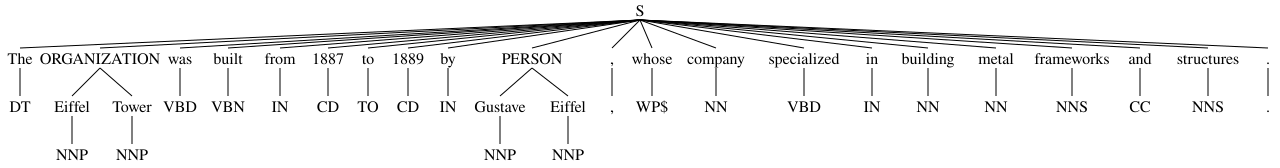

In [24]:
!pip3 install svgling
chunks = ne_chunk(tagged)
chunks

In [25]:
from nltk.tree import Tree

def extract_entities(tree):
    entities = []
    for subtree in tree.subtrees():
        if isinstance(subtree, Tree) and subtree.label() in {
            "PERSON", "ORGANIZATION", "GPE", "LOCATION",
            "DATE", "TIME", "MONEY", "PERCENT", "QUANTITY"
        }:
            text = " ".join(word for word, tag in subtree.leaves())
            entities.append((subtree.label(), text))
    return entities

entities = extract_entities(chunks)
print(entities)

[('ORGANIZATION', 'Eiffel Tower'), ('PERSON', 'Gustave Eiffel')]
